# 08 Macro Regime Panel

**Book study support notebook**  
**Purpose:** Build a reusable daily macro regime series for the FIRV study using local FRED data.


## Goals

1. Load local macro / rates regime inputs.
2. Define four practical regimes:
   - inflation shock
   - growth scare
   - stable carry
   - funding stress
3. Persist a daily regime series that other FIRV notebooks can import.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-26_fixed_income_relative_value_analysis_2e"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from quant_data.api import get_data

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

START = "2024-02-26"
END = "2026-02-27"
BOOK_PDF = Path(r"""/Users/zelin/Desktop/阅读学习/Fixed Income Relative Value Analysis + Website A Practitioner’s Guide to the Theory, Tools, and Trades 2nd.pdf""")
REGIME_PARQUET = STUDY_DIR / "macro_regime_daily.parquet"
REGIME_CSV = STUDY_DIR / "macro_regime_daily.csv"

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Book PDF exists:", BOOK_PDF.exists())
print("Repo root:", REPO_ROOT)
print("Study dir:", STUDY_DIR)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Book PDF exists: True
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy
Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-26_fixed_income_relative_value_analysis_2e


In [2]:
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"


def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
regime_inputs = load_fred_series(["SOFR", "DFEDTARU", "T10Y2Y", "T10Y3M", "T5YIE", "T10YIE"]).sort_index()
regime_inputs = regime_inputs.dropna().copy()

regime_inputs["funding_spread"] = regime_inputs["SOFR"] - regime_inputs["DFEDTARU"]
regime_inputs["curve_combo"] = 0.5 * (regime_inputs["T10Y2Y"] + regime_inputs["T10Y3M"])
regime_inputs["breakeven_avg"] = 0.5 * (regime_inputs["T5YIE"] + regime_inputs["T10YIE"])

regime_inputs.tail()


series_id   DFEDTARU  SOFR  T10Y2Y  T10Y3M  T10YIE  T5YIE  funding_spread  curve_combo  breakeven_avg
date                                                                                                 
2026-02-20      3.75  3.66    0.60    0.39    2.28   2.43           -0.09        0.495          2.355
2026-02-23      3.75  3.66    0.60    0.34    2.26   2.40           -0.09        0.470          2.330
2026-02-24      3.75  3.67    0.61    0.35    2.26   2.40           -0.08        0.480          2.330
2026-02-25      3.75  3.67    0.60    0.36    2.28   2.42           -0.08        0.480          2.350
2026-02-26      3.75  3.67    0.60    0.34    2.28   2.43           -0.08        0.470          2.355

In [4]:
thresholds = {
    "funding_stress_q80": float(regime_inputs["funding_spread"].quantile(0.8)),
    "curve_combo_q20": float(regime_inputs["curve_combo"].quantile(0.2)),
    "curve_combo_q60": float(regime_inputs["curve_combo"].quantile(0.6)),
    "breakeven_q80": float(regime_inputs["breakeven_avg"].quantile(0.8)),
    "breakeven_q35": float(regime_inputs["breakeven_avg"].quantile(0.35)),
}
thresholds


{'funding_stress_q80': -0.09999999999999964, 'curve_combo_q20': -0.6759999999999999, 'curve_combo_q60': 0.25, 'breakeven_q80': 2.4110000000000005, 'breakeven_q35': 2.3049999999999997}

In [5]:
def classify_regime(row, thresholds):
    if row["funding_spread"] >= thresholds["funding_stress_q80"]:
        return "funding stress"
    if row["curve_combo"] <= thresholds["curve_combo_q20"] and row["breakeven_avg"] <= thresholds["breakeven_q80"]:
        return "growth scare"
    if row["breakeven_avg"] >= thresholds["breakeven_q80"] and row["curve_combo"] > thresholds["curve_combo_q20"]:
        return "inflation shock"
    return "stable carry"

regime_inputs["regime"] = regime_inputs.apply(classify_regime, axis=1, thresholds=thresholds)
regime_inputs["regime_code"] = regime_inputs["regime"].map({
    "inflation shock": 0,
    "growth scare": 1,
    "stable carry": 2,
    "funding stress": 3,
})
regime_inputs[["funding_spread", "curve_combo", "breakeven_avg", "regime"]].tail(10)


series_id   funding_spread  curve_combo  breakeven_avg          regime
date                                                                  
2026-02-12           -0.10        0.505          2.370    stable carry
2026-02-13           -0.09        0.500          2.345  funding stress
2026-02-17           -0.04        0.490          2.325  funding stress
2026-02-18           -0.02        0.505          2.360  funding stress
2026-02-19           -0.08        0.500          2.360  funding stress
2026-02-20           -0.09        0.495          2.355  funding stress
2026-02-23           -0.09        0.470          2.330  funding stress
2026-02-24           -0.08        0.480          2.330  funding stress
2026-02-25           -0.08        0.480          2.350  funding stress
2026-02-26           -0.08        0.470          2.355  funding stress

In [6]:
regime_counts = regime_inputs["regime"].value_counts().rename_axis("regime").to_frame("days")
regime_counts


                 days
regime               
stable carry      201
funding stress    105
growth scare       99
inflation shock    95

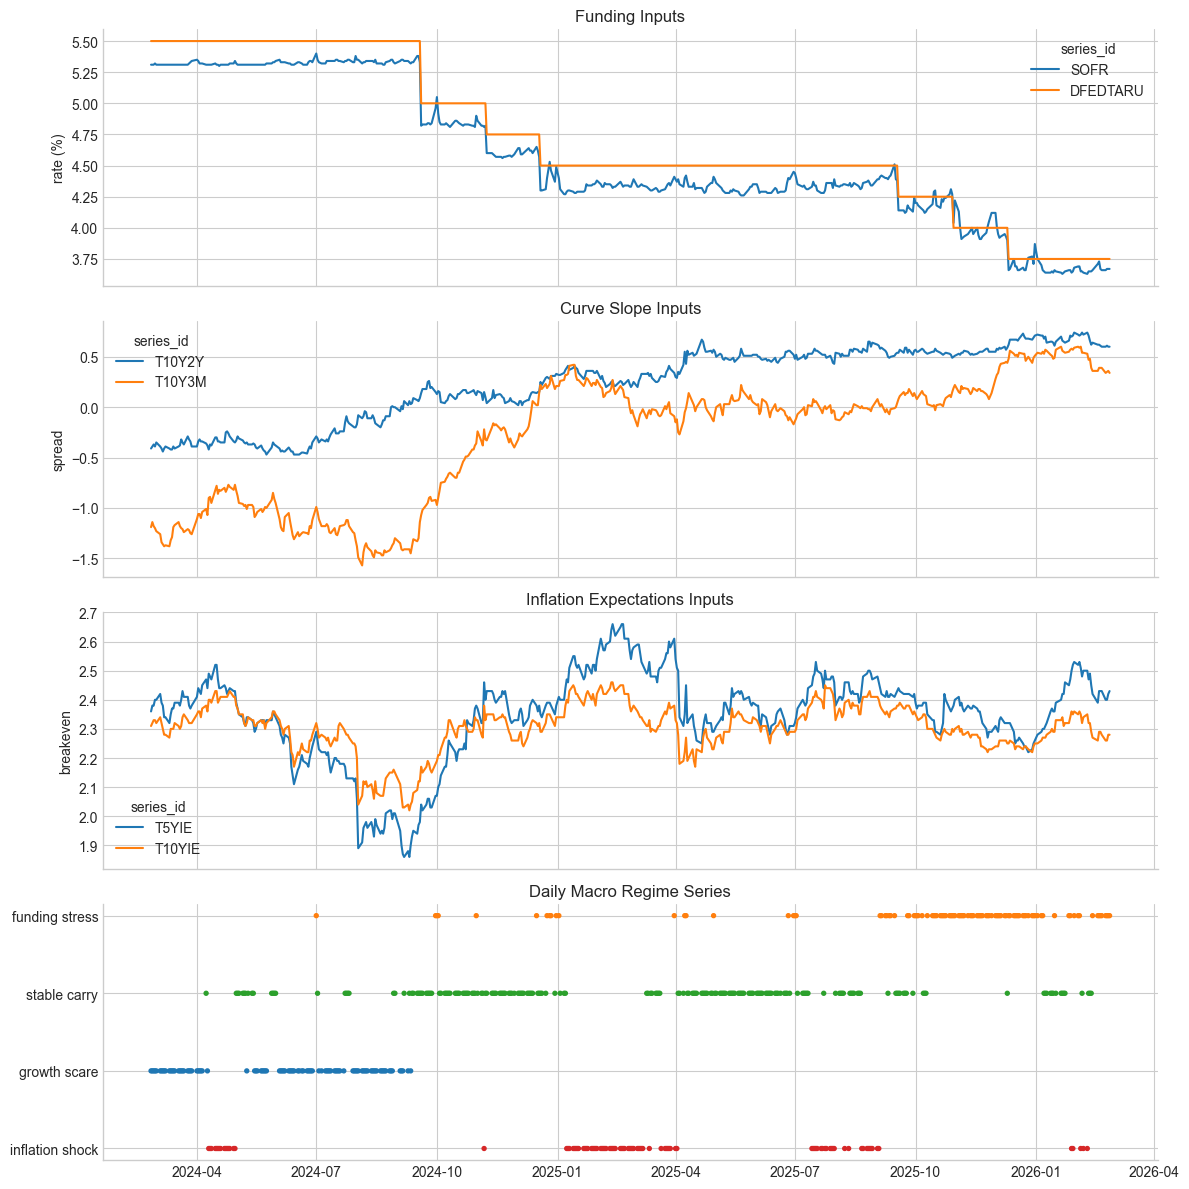

In [7]:
color_map = {
    "inflation shock": "tab:red",
    "growth scare": "tab:blue",
    "stable carry": "tab:green",
    "funding stress": "tab:orange",
}

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
regime_inputs[["SOFR", "DFEDTARU"]].plot(ax=axes[0], title="Funding Inputs")
axes[0].set_ylabel("rate (%)")

regime_inputs[["T10Y2Y", "T10Y3M"]].plot(ax=axes[1], title="Curve Slope Inputs")
axes[1].set_ylabel("spread")

regime_inputs[["T5YIE", "T10YIE"]].plot(ax=axes[2], title="Inflation Expectations Inputs")
axes[2].set_ylabel("breakeven")

axes[3].scatter(regime_inputs.index, regime_inputs["regime_code"], c=regime_inputs["regime"].map(color_map), s=8)
axes[3].set_yticks([0,1,2,3])
axes[3].set_yticklabels(["inflation shock", "growth scare", "stable carry", "funding stress"])
axes[3].set_title("Daily Macro Regime Series")
plt.tight_layout()
plt.show()


In [8]:
regime_output = regime_inputs[["SOFR", "DFEDTARU", "T10Y2Y", "T10Y3M", "T5YIE", "T10YIE", "funding_spread", "curve_combo", "breakeven_avg", "regime", "regime_code"]].copy()
regime_output.index.name = "date"
regime_output.to_parquet(REGIME_PARQUET)
regime_output.to_csv(REGIME_CSV)

print('saved regime parquet to', REGIME_PARQUET)
print('saved regime csv to', REGIME_CSV)
regime_output.tail()


saved regime parquet to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-26_fixed_income_relative_value_analysis_2e/macro_regime_daily.parquet
saved regime csv to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-26_fixed_income_relative_value_analysis_2e/macro_regime_daily.csv


series_id   SOFR  DFEDTARU  T10Y2Y  T10Y3M  T5YIE  T10YIE  funding_spread  curve_combo  breakeven_avg          regime  regime_code
date                                                                                                                              
2026-02-20  3.66      3.75    0.60    0.39   2.43    2.28           -0.09        0.495          2.355  funding stress            3
2026-02-23  3.66      3.75    0.60    0.34   2.40    2.26           -0.09        0.470          2.330  funding stress            3
2026-02-24  3.67      3.75    0.61    0.35   2.40    2.26           -0.08        0.480          2.330  funding stress            3
2026-02-25  3.67      3.75    0.60    0.36   2.42    2.28           -0.08        0.480          2.350  funding stress            3
2026-02-26  3.67      3.75    0.60    0.34   2.43    2.28           -0.08        0.470          2.355  funding stress            3

## Import contract for other notebooks

Other FIRV notebooks should load `macro_regime_daily.parquet` from this study folder and merge on the daily index.
